In [2]:
# Read Data
# Split Data x,y
# Scaling
# Train Test
# Build Model
# Predict
# Evaluation

# Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

# Read Data

In [11]:
diabetes_disease = pd.read_csv(r"C:\Users\User\Downloads\diabetes.csv")
diabetes_disease

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [13]:
diabetes_disease["Outcome"].unique()

array([1, 0], dtype=int64)

In [14]:
diabetes_disease.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
diabetes_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Split_Scaling_Data

In [20]:
x = diabetes_disease.iloc[: , 0:8]
y = diabetes_disease.iloc[: , -1]

In [21]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [22]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [23]:
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
x = x_scaler.fit_transform(x)

In [24]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

# Build Model

In [28]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear')
svm_model.fit(x_train , y_train)

SVC(kernel='linear')

# Evaluation

In [34]:
y_pred = svm_model.predict(x_test)

In [35]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
cnf_matrix = confusion_matrix(y_test , y_pred)
cnf_matrix

array([[81, 18],
       [19, 36]], dtype=int64)

<Axes: >

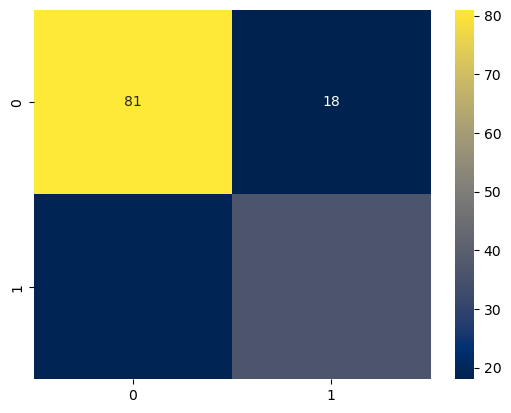

In [41]:
sns.heatmap(pd.DataFrame(cnf_matrix) , annot=True , cmap="cividis")

In [42]:
from sklearn.metrics import accuracy_score , recall_score , precision_score
accuracy_score = accuracy_score(y_test , y_pred)
recall = recall_score(y_test , y_pred)
precision = precision_score(y_test , y_pred)

In [43]:
print(f'{accuracy_score * 100} %')
print(f'{recall * 100} %')
print(f'{precision * 100} %')

75.97402597402598 %
65.45454545454545 %
66.66666666666666 %
